# Data Preprocessing Walkthrough
### HLLD Total Pressure Prediction — `src/data/preprocess.py`

This notebook walks through every step of the preprocessing pipeline, explaining **what** is done, **why** it is done, and **what the data looks like** at each stage.

The pipeline has three stages:
1. **Load** raw samples from `data/raw/dataset_mignone.npz`
2. **Normalise** the 15 input features with standard (z-score) normalisation
3. **Split** the data 80 / 10 / 10 into train / val / test and save to `data/splits/`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # make src importable

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

---
## 1. Load raw data

The raw dataset is stored as a compressed NumPy archive (`.npz`) with two arrays:

| Key | Shape | Description |
|-----|-------|-------------|
| `inputs` | `(N, 15)` | 15 primitive-variable inputs describing a Riemann problem |
| `targets` | `(N,)` | Total pressure `p_tot*` — the quantity the network must predict |

### What are the 15 inputs?
Each sample encodes a **left state**, a **right state**, and a **shared normal magnetic field** component `Bx`:

```
Index  Variable  Description
  0    rho_L     Left density
  1    vx_L      Left x-velocity
  2    vy_L      Left y-velocity
  3    vz_L      Left z-velocity
  4    p_L       Left gas pressure
  5    By_L      Left y-magnetic field
  6    Bz_L      Left z-magnetic field
  7    rho_R     Right density
  8    vx_R      Right x-velocity
  9    vy_R      Right y-velocity
 10    vz_R      Right z-velocity
 11    p_R       Right gas pressure
 12    By_R      Right y-magnetic field
 13    Bz_R      Right z-magnetic field
 14    Bx        Shared normal B-field (same on both sides by jump conditions)
```

The target `p_tot*` is the **total pressure at the intermediate state** — the value the HLLD Riemann solver needs to determine the wave structure.

In [2]:
raw = np.load("../data/raw/dataset_mignone.npz")
X_raw = raw["inputs"]    # (N, 15)
y_raw = raw["targets"]   # (N,)

N, D = X_raw.shape
print(f"Dataset size : {N:,} samples")
print(f"Input features : {D}")
print(f"Target shape   : {y_raw.shape}")
print(f"\nX dtype : {X_raw.dtype}")
print(f"y dtype : {y_raw.dtype}")

Dataset size : 1,000,000 samples
Input features : 15
Target shape   : (1000000,)

X dtype : float64
y dtype : float64


### Quick summary statistics of the raw inputs

In [3]:
feature_names = [
    r"$\rho_L$", r"$v_{x,L}$", r"$v_{y,L}$", r"$v_{z,L}$", r"$p_L$", r"$B_{y,L}$", r"$B_{z,L}$",
    r"$\rho_R$", r"$v_{x,R}$", r"$v_{y,R}$", r"$v_{z,R}$", r"$p_R$", r"$B_{y,R}$", r"$B_{z,R}$",
    r"$B_x$"
]

import pandas as pd
stats_df = pd.DataFrame({
    "feature" : feature_names,
    "min"     : X_raw.min(axis=0),
    "mean"    : X_raw.mean(axis=0),
    "max"     : X_raw.max(axis=0),
    "std"     : X_raw.std(axis=0),
})
stats_df

,feature,min,mean,max,std
0,$\rho_L$,0.125893,14.951175,99.999848,22.905906
1,"$v_{x,L}$",-0.999135,0.000420,0.999126,0.565981
2,"$v_{y,L}$",-0.999135,0.000465,0.999156,0.565626
3,"$v_{z,L}$",-0.999150,-0.000426,0.999097,0.565474
4,$p_L$,0.033294,208.511675,2352.270683,436.031690
5,"$B_{y,L}$",-9.996616,0.006548,9.998159,4.087794
6,"$B_{z,L}$",-9.998024,-0.003697,9.999285,4.084705
7,$\rho_R$,0.125893,14.964559,99.998801,22.909204
8,"$v_{x,R}$",-0.999103,0.000316,0.999085,0.565329
9,"$v_{y,R}$",-0.999124,-0.000375,0.999073,0.565730


Notice that the features span **very different numerical ranges** — densities can be tiny (< 0.001) while magnetic fields can reach ±5. This is exactly why normalisation is essential before feeding data into a neural network.

### Distribution of raw input features

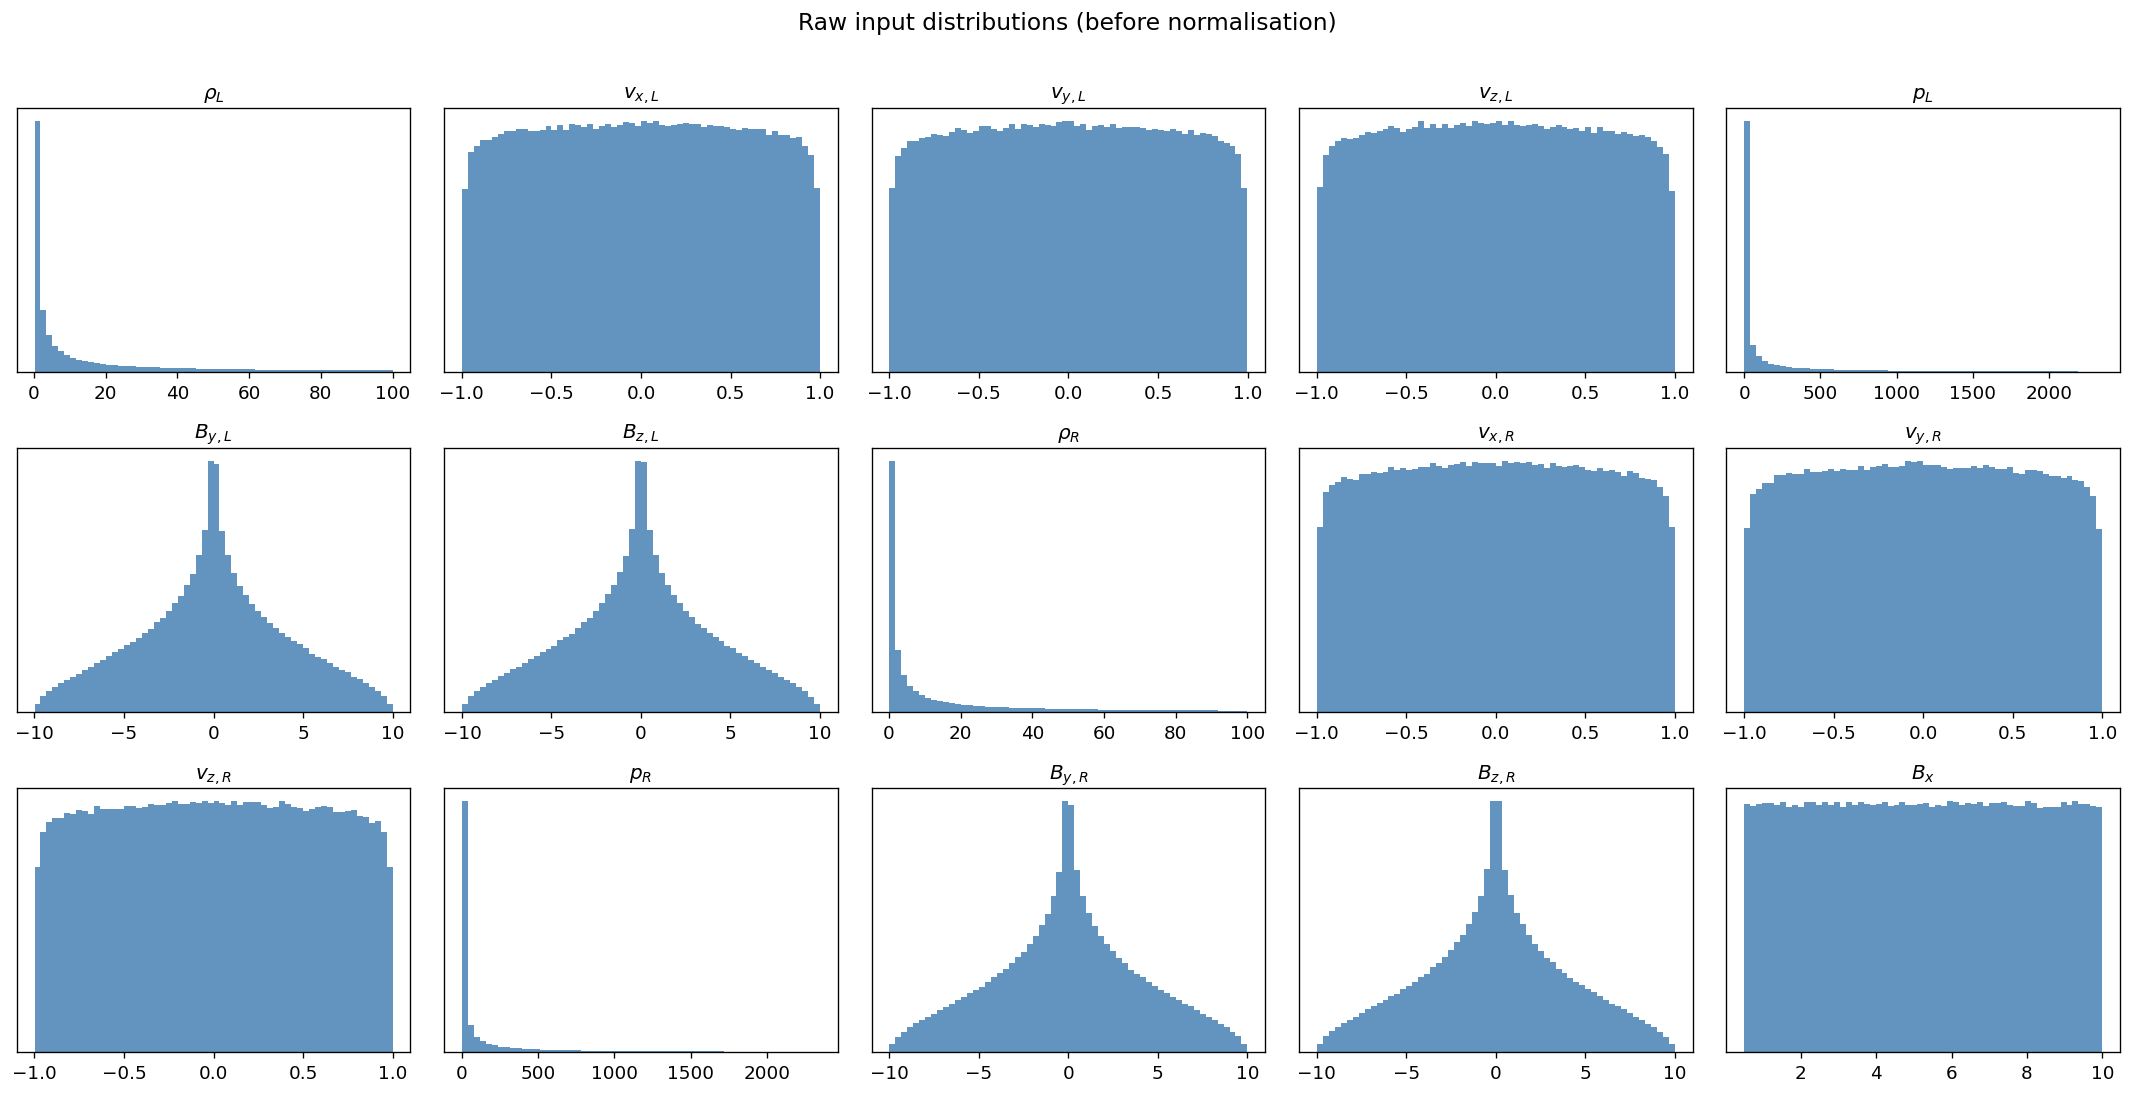

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(18, 9))
axes = axes.flatten()

for i in range(15):
    axes[i].hist(X_raw[:, i], bins=60, color="steelblue", edgecolor="none", alpha=0.85)
    axes[i].set_title(feature_names[i], fontsize=12)
    axes[i].set_yticks([])

fig.suptitle("Raw input distributions (before normalisation)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Normalisation

The preprocessing script applies **standard (z-score) normalisation** to every input feature:

$$\hat{x}_j = \frac{x_j - \mu_j}{\sigma_j + \epsilon}$$

where:
- $\mu_j$ is the mean of feature $j$ over the **full dataset** (before splitting)
- $\sigma_j$ is the standard deviation of feature $j$
- $\epsilon = 10^{-12}$ is a small constant added for numerical stability (prevents division by zero for constant features)

**Why normalise inputs?**
- Gradient descent converges much faster when all features are on a similar scale.
- Without normalisation, features with large variance dominate the loss surface, making it harder to learn useful signal from smaller-scale features.
- The SiLU activations used here saturate less predictably with very large inputs, making z-scoring especially valuable.

**Why normalise before splitting?**
Here the statistics are computed on the full 100k dataset, which is an acceptable shortcut when the data is i.i.d. (all samples drawn from the same generative process). In a scenario with distribution shift between splits, you would compute stats on the training set only.

**The target `y` is NOT normalised.** The `PhysicsInformedLoss` operates in physical units, so keeping the target in its original scale makes the physics penalty meaningful.

In [5]:
# Reproduce exactly what preprocess.py does
mu    = X_raw.mean(axis=0)           # shape (15,)
sigma = X_raw.std(axis=0) + 1e-12   # shape (15,)

X_norm = (X_raw - mu) / sigma

print("Normalisation statistics:")
print(f"  mu    range : [{mu.min():.4f}, {mu.max():.4f}]")
print(f"  sigma range : [{sigma.min():.4f}, {sigma.max():.4f}]")
print()
print("Post-normalisation check (should be ~0 mean, ~1 std per feature):")
print(f"  mean  range : [{X_norm.mean(axis=0).min():.2e}, {X_norm.mean(axis=0).max():.2e}]")
print(f"  std   range : [{X_norm.std(axis=0).min():.4f}, {X_norm.std(axis=0).max():.4f}]")

Normalisation statistics:
  mu    range : [-0.0053, 208.6440]
  sigma range : [0.5653, 436.0317]

Post-normalisation check (should be ~0 mean, ~1 std per feature):
  mean  range : [-2.37e-14, 9.29e-14]
  std   range : [1.0000, 1.0000]


### Before vs After normalisation — side-by-side

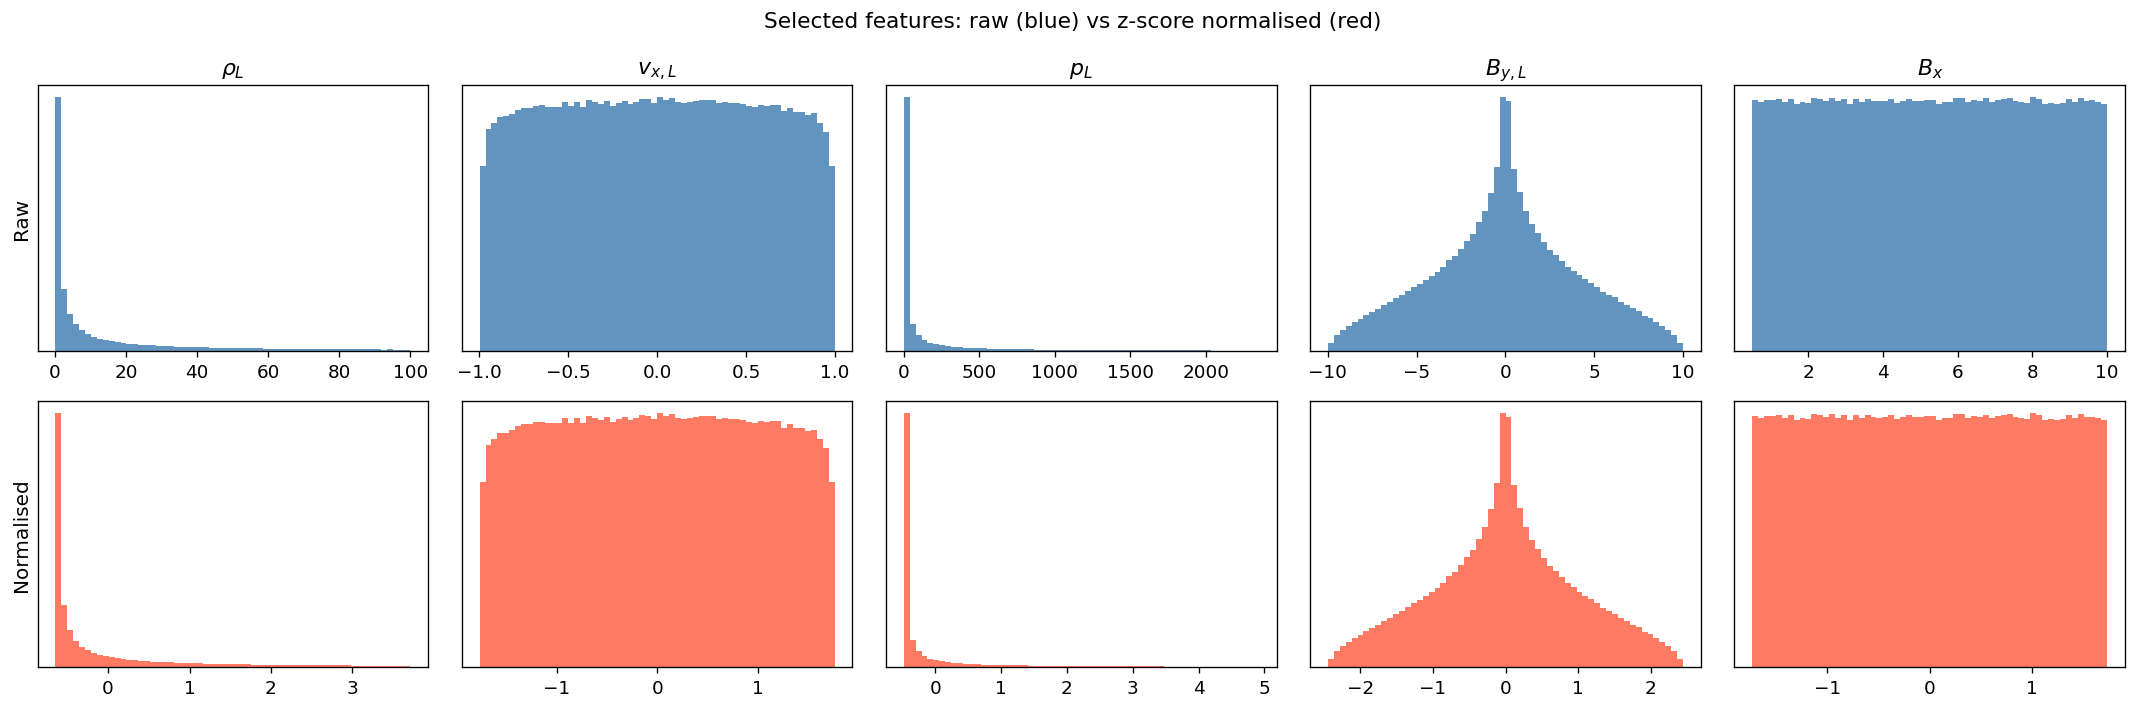

In [6]:
# Show one representative feature per column of primitives
showcase = [0, 1, 4, 5, 14]   # rho_L, vx_L, p_L, By_L, Bx
labels   = [feature_names[i] for i in showcase]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for col, (idx, lbl) in enumerate(zip(showcase, labels)):
    # Raw
    axes[0, col].hist(X_raw[:, idx], bins=60, color="steelblue", edgecolor="none", alpha=0.85)
    axes[0, col].set_title(lbl)
    axes[0, col].set_yticks([])
    # Normalised
    axes[1, col].hist(X_norm[:, idx], bins=60, color="tomato", edgecolor="none", alpha=0.85)
    axes[1, col].set_yticks([])

axes[0, 0].set_ylabel("Raw",        fontsize=12)
axes[1, 0].set_ylabel("Normalised", fontsize=12)
fig.suptitle("Selected features: raw (blue) vs z-score normalised (red)", fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Saving normalisation statistics

The mean `mu` and standard deviation `sigma` computed above are saved to `data/processed/norm_stats.npz`. This is essential for **inference time**: when the trained model is applied to new Riemann problems, those new inputs must be normalised using the **exact same** statistics from training — not re-computed on the new data.

In [7]:
stats_path = "../data/processed/norm_stats.npz"
saved = np.load(stats_path)
print("Keys saved in norm_stats.npz:", list(saved.keys()))
print("mu shape   :", saved["mu"].shape)
print("sigma shape:", saved["sigma"].shape)

Keys saved in norm_stats.npz: ['mu', 'sigma']
mu shape   : (15,)
sigma shape: (15,)


---
## 4. Train / Val / Test split

After normalisation, the data is **shuffled and split** into three sets:

| Split | Fraction | Purpose |
|-------|----------|---------|
| `train` | 80 % | Used to compute gradients and update model weights |
| `val`   | 10 % | Monitored during training to detect overfitting and drive the LR scheduler |
| `test`  | 10 % | Held out completely — used only for final evaluation after training |

The shuffle uses a **fixed random seed** (`seed=42` from the config by default, or the value set in `data.seed`). Fixing the seed guarantees:
- Reproducibility: re-running preprocess produces the same splits.
- No data leakage: the same sample cannot appear in both train and val.

The implementation uses `numpy.random.default_rng` (the modern NumPy RNG) rather than the legacy `np.random.shuffle`, which provides better statistical properties.

In [8]:
seed = 42   # as used in preprocess.py
rng  = np.random.default_rng(seed)
idx  = rng.permutation(N)

n_train = int(N * 0.80)   # 80 000
n_val   = int(N * 0.10)   # 10 000
# test  = remaining       # 10 000

idx_train = idx[:n_train]
idx_val   = idx[n_train:n_train + n_val]
idx_test  = idx[n_train + n_val:]

print(f"Train : {len(idx_train):6,} samples  ({100*len(idx_train)/N:.0f}%)")
print(f"Val   : {len(idx_val):6,} samples  ({100*len(idx_val)/N:.0f}%)")
print(f"Test  : {len(idx_test):6,} samples  ({100*len(idx_test)/N:.0f}%)")

Train : 800,000 samples  (80%)
Val   : 100,000 samples  (10%)
Test  : 100,000 samples  (10%)


### Verify splits preserve the same distribution

A good split should not accidentally concentrate a particular range of values in one subset. We check this by comparing the target distribution across splits.

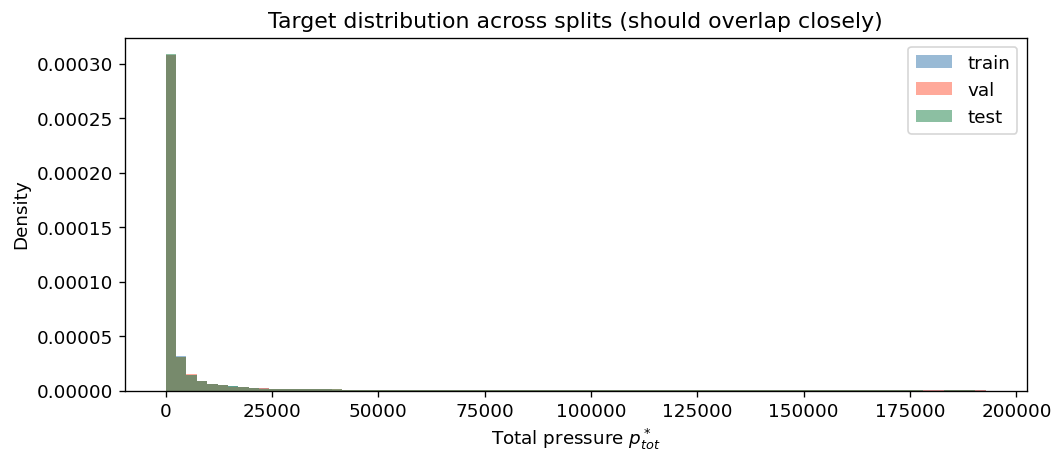

Target stats per split:
  train  mean=9887.9644  std=54224.8294  min=0.0001  max=4664142.0434
  val    mean=9928.0436  std=53162.8470  min=0.0128  max=2041814.8970
  test   mean=10043.0841  std=54640.7408  min=0.0002  max=3400593.7034


In [9]:
y_train = y_raw[idx_train]
y_val   = y_raw[idx_val]
y_test  = y_raw[idx_test]

bins = np.linspace(y_raw.min(), np.percentile(y_raw, 99), 80)

fig, ax = plt.subplots(figsize=(9, 4))
for arr, label, color in [(y_train, "train", "steelblue"),
                           (y_val,   "val",   "tomato"),
                           (y_test,  "test",  "seagreen")]:
    ax.hist(arr, bins=bins, density=True, alpha=0.55, label=label, color=color)

ax.set_xlabel(r"Total pressure $p_{tot}^*$")
ax.set_ylabel("Density")
ax.set_title("Target distribution across splits (should overlap closely)")
ax.legend()
plt.tight_layout()
plt.show()

print("Target stats per split:")
for name, arr in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  {name:5s}  mean={arr.mean():.4f}  std={arr.std():.4f}  min={arr.min():.4f}  max={arr.max():.4f}")

---
## 5. Output files

The script writes three `.npz` files to `data/splits/` — one per split — each containing two arrays:

```
data/splits/
├── train.npz   (inputs: (80000, 15),  targets: (80000,))
├── val.npz     (inputs: (10000, 15),  targets: (10000,))
└── test.npz    (inputs: (10000, 15),  targets: (10000,))
```

The `HLLDDataset` class in `src/data/dataset.py` reads these files directly and wraps them in a PyTorch `Dataset` for use by the training loop.

In [10]:
for split_name in ["train", "val", "test"]:
    d = np.load(f"../data/splits/{split_name}.npz")
    print(f"{split_name:5s}  inputs: {d['inputs'].shape}   targets: {d['targets'].shape}")

train  inputs: (80000, 15)   targets: (80000,)
val    inputs: (10000, 15)   targets: (10000,)
test   inputs: (10000, 15)   targets: (10000,)


---
## 6. Full pipeline summary

```
data/raw/dataset_mignone.npz
       │
       ▼
 load_raw()              → X (100000, 15),  y (100000,)
       │
       ▼
 normalize(method='standard')
   X̂_j = (X_j − μ_j) / (σ_j + 1e-12)
   saves μ, σ  →  data/processed/norm_stats.npz
       │
       ▼
 split(seed=42)
   shuffle with np.random.default_rng(seed)
   80% / 10% / 10%
       │
       ▼
 data/splits/
   train.npz   (80 000 samples)
   val.npz     (10 000 samples)
   test.npz    (10 000 samples)
```

To run this pipeline from the command line:

```bash
python -m src.data.preprocess --config configs/default-mignone.yaml
```